## ✅ TASK 3: Data Visualization
#### ● Transform raw data into visual formats like charts, graphs, and dashboards.
#### ● Use tools like Matplotlib, Seaborn, or Tableau for creating visuals.
#### ● Design visuals that enhance understanding and reveal insights clearly.
#### ● Craft compelling data stories that support decision-making.
#### ● Build a strong portfolio with impactful and well-designed visualizations.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../data/car_prices.csv")

In [15]:
df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [16]:
# Örnek: Qiymət sütunundakı kənar göstəricilər (outliers)
#plt.boxplot(df['sellingprice'].dropna())
#plt.title('Qiymət Outlier Analizi')
#plt.show()

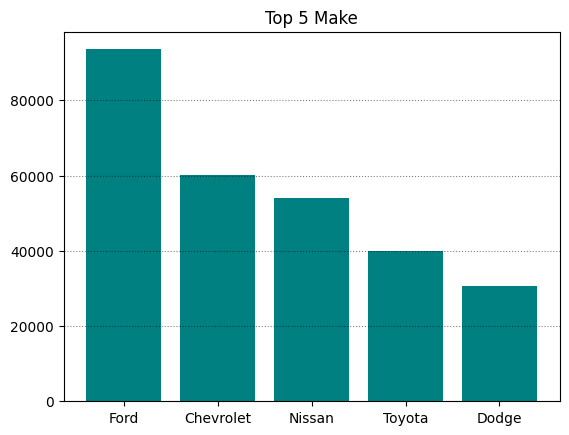

In [17]:
# Örnek: Markaların satış sayı
top5=df['make'].value_counts().head(5)
plt.bar(top5.index, top5.values, color='teal')
plt.title('Top 5 Make')
plt.grid(axis='y', linestyle=':', alpha=0.5,c='black')
plt.show()

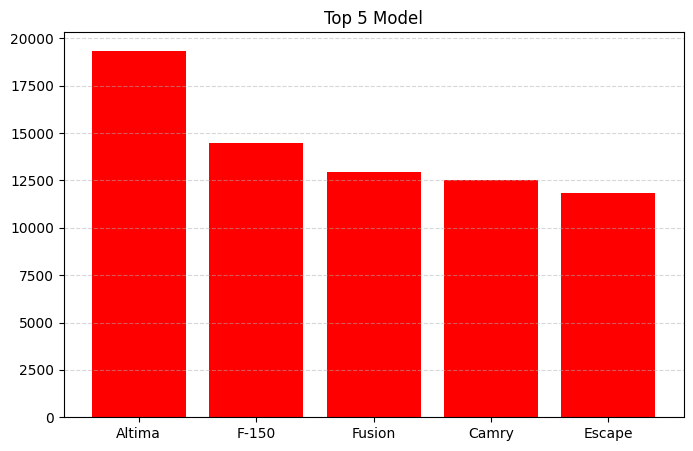

In [18]:
plt.figure(figsize=(8,5))
top5=df['model'].value_counts().head(5)
plt.bar(top5.index,top5.values,color='red')
plt.title('Top 5 Model')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

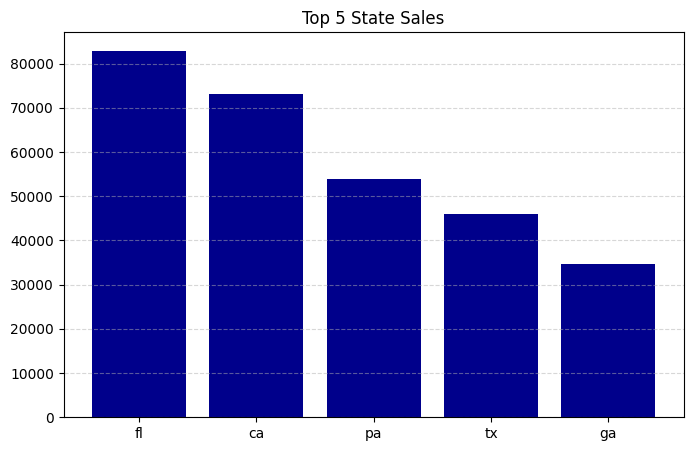

In [19]:
plt.figure(figsize=(8,5))
top5_state=df['state'].value_counts().head(5)
plt.bar(top5_state.index,top5_state.values,color='darkblue')
plt.title('Top 5 State Sales')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

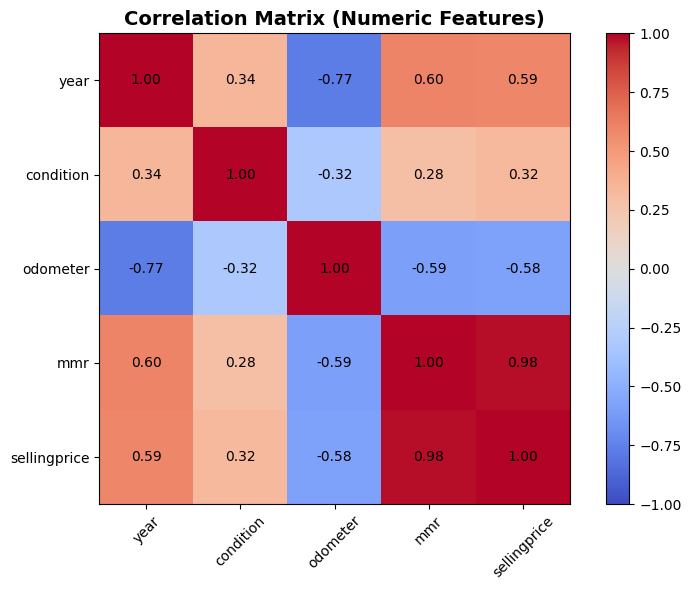

In [20]:
corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 6))

cax = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(cax)

cols = corr_matrix.columns
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", 
                 ha='center', va='center', color='black', fontsize=10)

plt.title('Correlation Matrix (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
num_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
corr_matrix = df[num_cols].corr().round(2)

print(corr_matrix)

              year  condition  odometer   mmr  sellingprice
year          1.00       0.34     -0.77  0.60          0.59
condition     0.34       1.00     -0.32  0.28          0.32
odometer     -0.77      -0.32      1.00 -0.59         -0.58
mmr           0.60       0.28     -0.59  1.00          0.98
sellingprice  0.59       0.32     -0.58  0.98          1.00


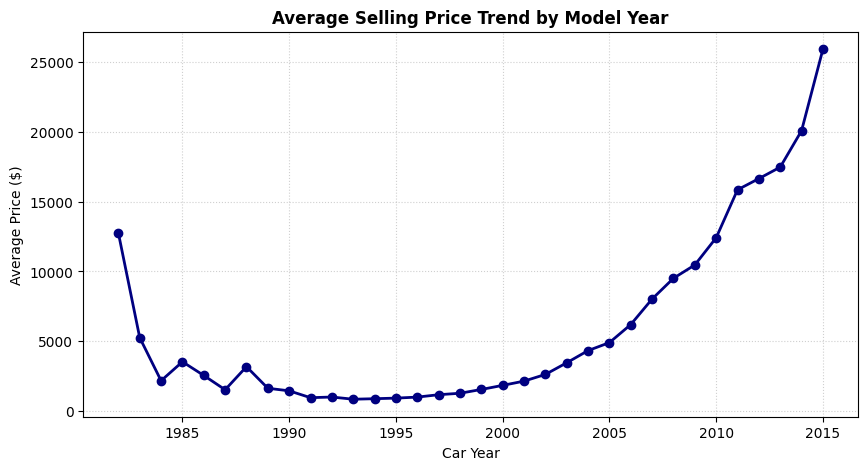

In [22]:
avg_price_year=df.groupby('year')['sellingprice'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_price_year.index,avg_price_year.values,color='navy',marker='o',linewidth='2')
plt.title('Average Selling Price Trend by Model Year', fontsize=12, fontweight='bold')
plt.xlabel('Car Year')
plt.ylabel('Average Price ($)')
plt.grid(True,linestyle=':',alpha=0.6)
plt.show()

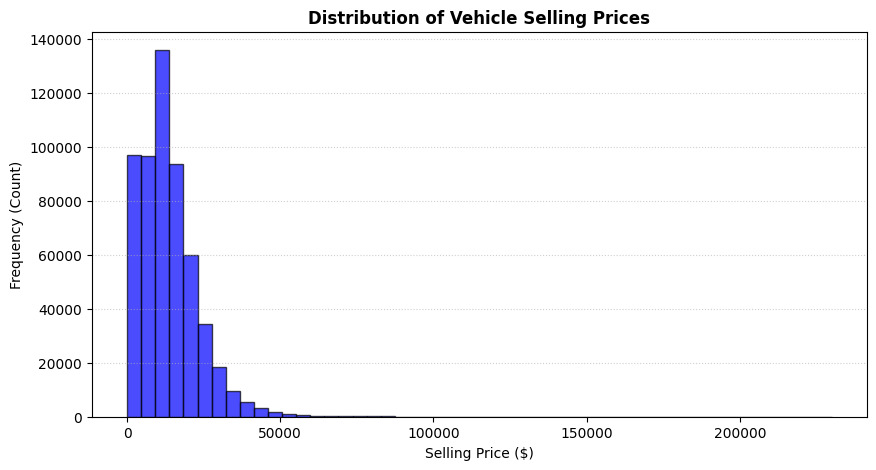

In [23]:
plt.figure(figsize=(10,5))
plt.hist(df['sellingprice'], bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Vehicle Selling Prices', fontsize=12, fontweight='bold')
plt.xlabel('Selling Price ($)')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

In [44]:
# 1. Rəqəmdən ibarət olan sürüşmüş dəyərləri və '-' simvolunu NaN edirik
df['color'] = df['color'].replace('—', np.nan)
df['color'] = df['color'].apply(lambda x: np.nan if str(x).isdigit() else x)

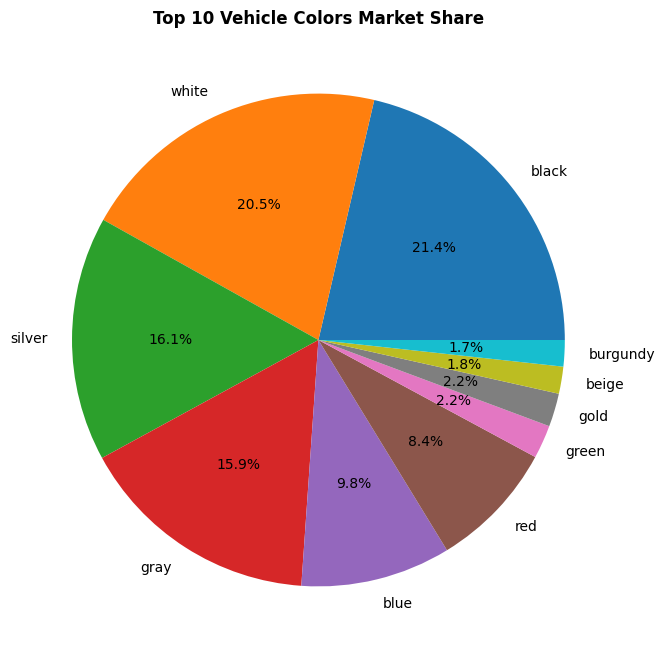

In [43]:
plt.figure(figsize=(8, 8))
top10_colors=df['color'].value_counts().head(10)
plt.pie(top10_colors.values,labels=top10_colors.index,autopct='%1.1f%%')
plt.title('Top 10 Vehicle Colors Market Share', fontsize=12, fontweight='bold')
plt.show()

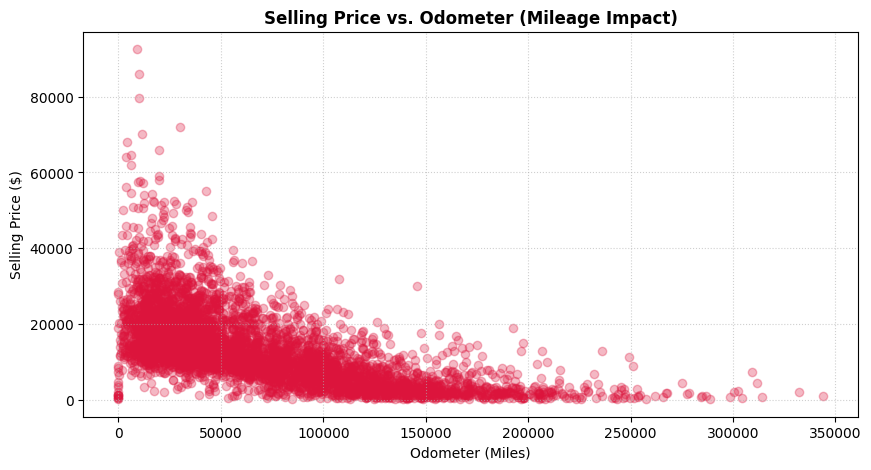

In [119]:
# Məlumat çoxdursa, qrafik rahat işləsin deyə 5000 nümünə seçirik

sample_df = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 5))
plt.scatter(sample_df['odometer'], sample_df['sellingprice'], alpha=0.3, color='crimson')

plt.title('Selling Price vs. Odometer (Mileage Impact)', fontsize=12, fontweight='bold')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Selling Price ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()